In [1]:
import os
import sys

os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from gjepa.utils.config import load_and_resolve_config

sns.set_theme("notebook")
import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

In [3]:
root_dir = Path("data/experiments/ablation_clustering")

res = []
for m_file in root_dir.rglob("metrics.json"):
    with m_file.open() as file:
        metrics = json.load(file)

    h_file = m_file.parent / "hparams.yaml"
    hparams = load_and_resolve_config(h_file)["config"]

    current_res = {
        "name": hparams["training"]["experiment_name"],
        "dataset": hparams["dataset"]["name"],
        "pos_enc": hparams["pos_encoding"]["name"],
        "num_clusters": hparams["dataset"]["num_partitions"],
        "num_targets": hparams["model"]["num_targets"],
    }
    current_res |= {"test_F1": metrics["test_F1"]}
    res.append(current_res)

res = pd.DataFrame(res)
res.head()

,name,dataset,pos_enc,num_clusters,num_targets,test_F1
0,ablation_clustering/Amazon-CS_node2vec_gjepa_s...,Amazon-CS,node2vec,500,4,0.834817
1,ablation_clustering/Amazon-CS_node2vec_gjepa_s...,Amazon-CS,node2vec,500,4,0.823202
2,ablation_clustering/Amazon-CS_node2vec_gjepa_s...,Amazon-CS,node2vec,500,4,0.830140
3,ablation_num_partitions/WikiCS_node2vec_gjepa_...,WikiCS,node2vec,100,8,0.755200
4,ablation_num_partitions/WikiCS_node2vec_gjepa_...,WikiCS,node2vec,100,8,0.758691


In [4]:
def plot_best_vs_best(param, ylim: tuple | None = None):
    res_grp = res.groupby(["name", "dataset", param])["test_F1"].agg(["mean", "std"])
    pos_enc_compare = res_grp.loc[
        res_grp.groupby(["dataset", param])["mean"].idxmax()
    ].reset_index()["name"]

    g = sns.catplot(
        data=res[res["name"].isin(pos_enc_compare)],
        x=param,
        y="test_F1",
        col="dataset",
        kind="bar",
        sharey=False,
    )
    if ylim is not None:
        g.set(ylim=ylim)
    g.fig.suptitle(f"Best models with varying {param}")
    g.fig.tight_layout()
    return g

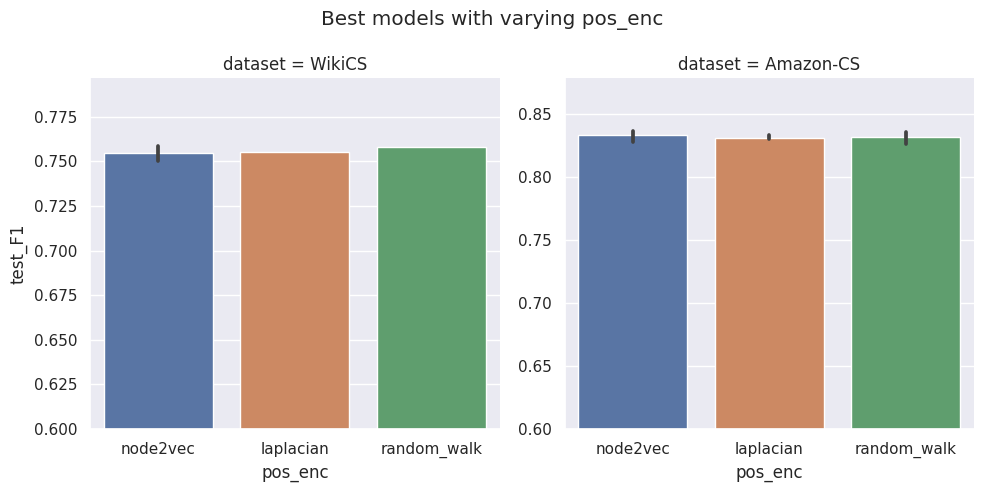

In [5]:
plot_best_vs_best("pos_enc", (0.6, None))

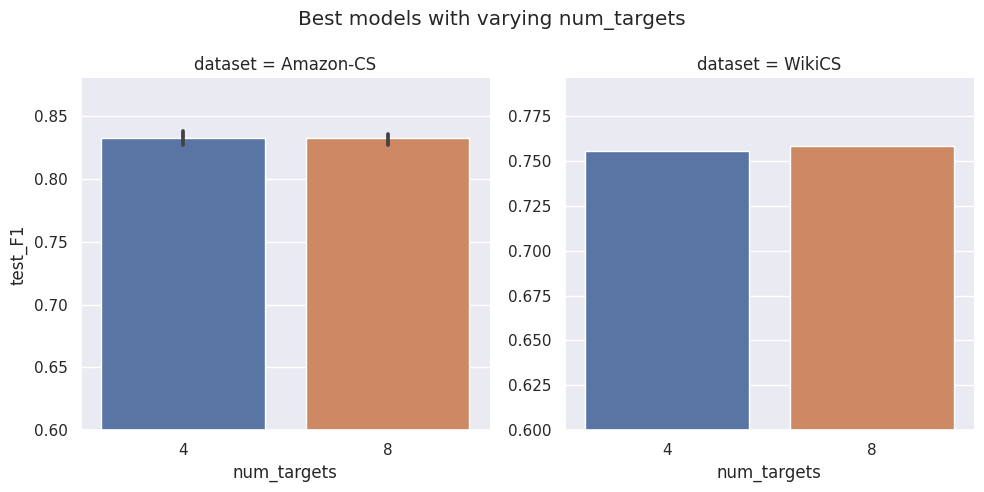

In [6]:
plot_best_vs_best("num_targets", (0.6, None))

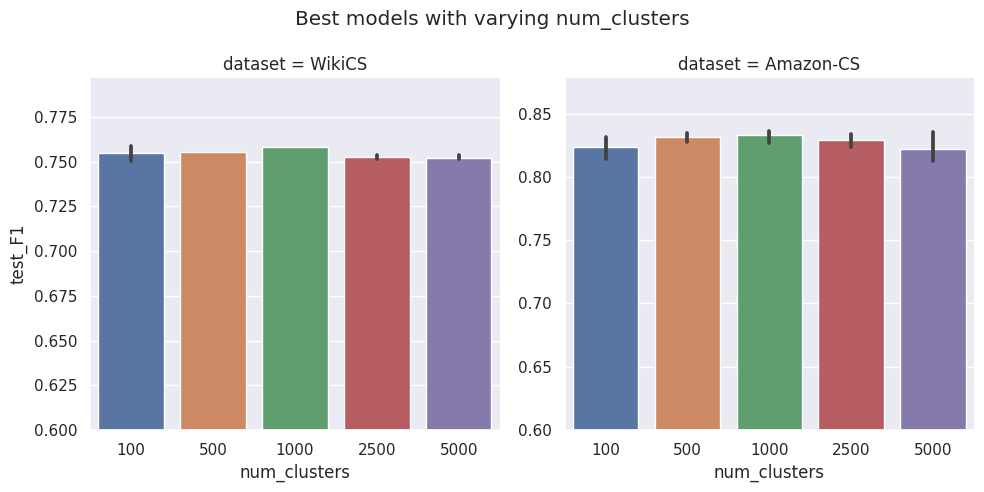

In [7]:
plot_best_vs_best("num_clusters", (0.6, None))